# PART 12

Haikal Ali_1103223071_TK46GAB

# Bab 12 - Least Squares Applications



## Inti Materi

Bab ini menunjukkan aplikasi least squares pada data nyata dan contoh kecil. Materinya mencakup prediksi jumlah rental sepeda berdasarkan cuaca, penggunaan `np.linalg.lstsq`, tabel regresi dengan `statsmodels`, multicollinearity, regularization, polynomial regression, dan grid search.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
  import statsmodels.api as sm
except ImportError:
  sm = None

np.set_printoptions(precision=3, suppress=True)

In [2]:
def r2_score_manual(y, yhat):
  y = np.asarray(y).reshape(-1)
  yhat = np.asarray(yhat).reshape(-1)
  ss_res = np.sum((y - yhat)**2)
  ss_tot = np.sum((y - np.mean(y))**2)
  return 1 - ss_res / ss_tot


def fit_lstsq(X, y):
  beta = np.linalg.lstsq(X, y, rcond=None)[0]
  yhat = X @ beta
  r2 = r2_score_manual(y, yhat)
  return beta, yhat, r2

## Predicting Bike Rentals Based on Weather

Dataset pada materi adalah data rental sepeda Seoul. Variabel dependen adalah `Rented Bike Count`, sedangkan beberapa variabel cuaca digunakan sebagai regressor, misalnya `Rainfall(mm)`, `Seasons`, dan `Temperature(°C)`. Materi menekankan bahwa data perlu diperiksa secara visual sebelum model statistik diinterpretasikan.

Cell berikut memuat dataset. Upload file dataset dengan nama `SeoulBikeData.csv` atau upload file CSV ketika diminta oleh Colab.

In [4]:
from pathlib import Path

csv_path = Path('SeoulBikeData.csv')

if not csv_path.exists():
  try:
    from google.colab import files
    uploaded = files.upload()
    csv_path = Path(next(iter(uploaded.keys())))
  except Exception as e:
    raise FileNotFoundError(
      "Dataset Seoul Bike belum ada. Upload file CSV dataset yang disebutkan di materi, "
      "lalu beri nama SeoulBikeData.csv atau pilih file saat upload."
    ) from e

data = pd.read_csv(csv_path, encoding='unicode_escape')
data.columns = data.columns.str.strip()

print(data.shape)
data.head()

Saving SeoulBikeData.csv to SeoulBikeData.csv
(8760, 14)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [5]:
# Preprocessing sesuai kebutuhan model pada materi.
# Seasons dikonversi menjadi 0/1: Autumn/Winter = 0, Spring/Summer = 1.
if data['Seasons'].dtype == object:
  data['Seasons'] = data['Seasons'].replace({
    'Autumn': 0,
    'Winter': 0,
    'Spring': 1,
    'Summer': 1
  }).astype(float)

# Date dipakai hanya untuk plot jika tersedia.
if 'Date' in data.columns:
  data['Date'] = pd.to_datetime(data['Date'], dayfirst=True, errors='coerce')

data[['Rented Bike Count', 'Rainfall(mm)', 'Seasons']].head()

/tmp/ipykernel_1791/2113787512.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Seasons'] = data['Seasons'].replace({


,Rented Bike Count,Rainfall(mm),Seasons
0,254,0.0,0.0
1,204,0.0,0.0
2,173,0.0,0.0
3,107,0.0,0.0
4,78,0.0,0.0


### Visualisasi awal

Materi menunjukkan bahwa `Rainfall(mm)` bersifat sparse: sebagian besar nilainya nol, dengan sebagian kecil nilai nonzero. Ini penting karena hubungan antara rainfall dan rental sepeda tidak terlihat linear sederhana.

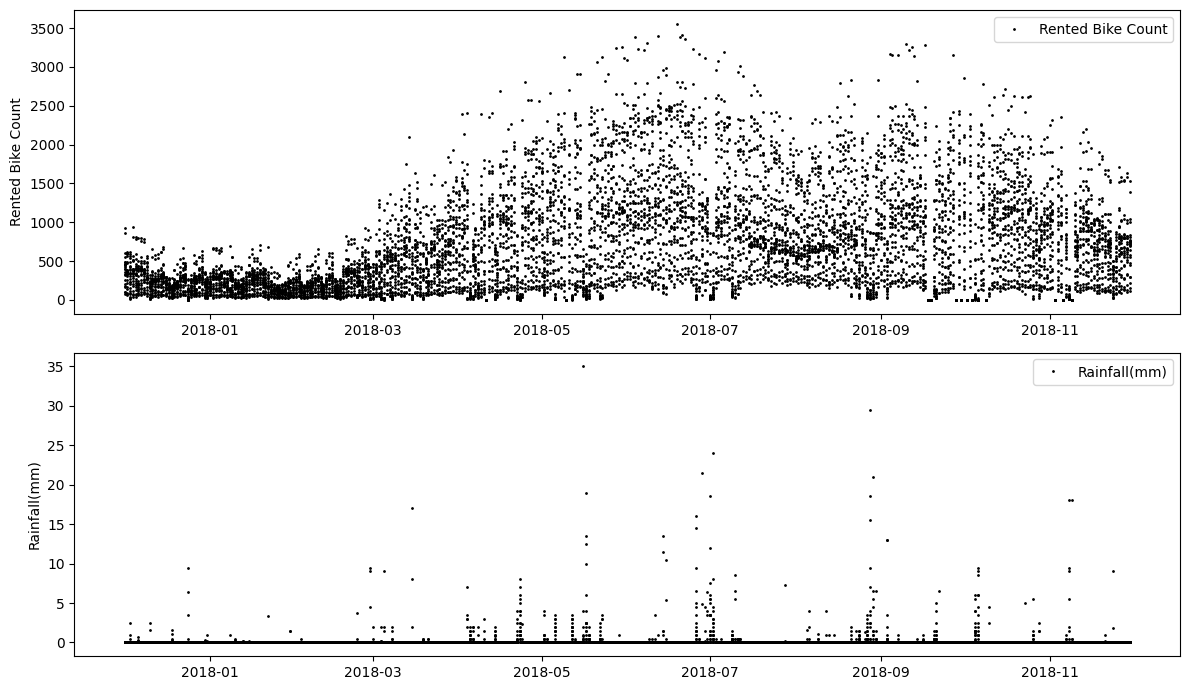

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

x_axis = data['Date'] if 'Date' in data.columns else np.arange(len(data))

axes[0].plot(x_axis, data['Rented Bike Count'], 'k.', markersize=2, label='Rented Bike Count')
axes[0].set_ylabel('Rented Bike Count')
axes[0].legend()

axes[1].plot(x_axis, data['Rainfall(mm)'], 'k.', markersize=2, label='Rainfall(mm)')
axes[1].set_ylabel('Rainfall(mm)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Correlation matrix

Correlation matrix digunakan untuk melihat hubungan linear antarvariabel. Pada materi, bike rental count cenderung positif terhadap hour dan temperature, serta negatif terhadap rainfall.

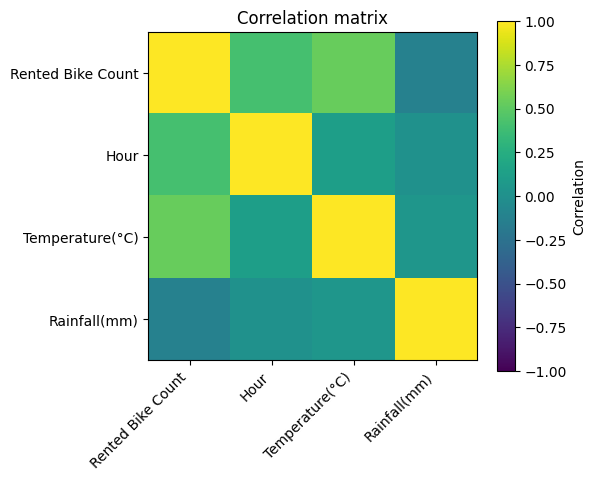

,Rented Bike Count,Hour,Temperature(°C),Rainfall(mm)
Rented Bike Count,1.000000,0.410257,0.538558,-0.123074
Hour,0.410257,1.000000,0.124114,0.008715
Temperature(°C),0.538558,0.124114,1.000000,0.050282
Rainfall(mm),-0.123074,0.008715,0.050282,1.000000


In [7]:
cols_corr = ['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Rainfall(mm)']
cols_corr = [c for c in cols_corr if c in data.columns]

corrmat = data[cols_corr].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corrmat, vmin=-1, vmax=1)
plt.xticks(range(len(cols_corr)), cols_corr, rotation=45, ha='right')
plt.yticks(range(len(cols_corr)), cols_corr)
plt.colorbar(label='Correlation')
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

corrmat

## Least Squares untuk Rainfall dan Seasons

Design matrix pada materi berisi kolom `Rainfall(mm)`, `Seasons`, dan intercept. Model di-fit menggunakan ordinary least squares dengan `np.linalg.lstsq`.

In [8]:
# Create a design matrix and add an intercept
X_rain_season = data[['Rainfall(mm)', 'Seasons']].to_numpy()
X_rain_season = np.append(X_rain_season, np.ones((X_rain_season.shape[0], 1)), axis=1)

# Extract DV
y_bike = data[['Rented Bike Count']].to_numpy()

# Fit the model to the data using least squares
beta_rain_season = np.linalg.lstsq(X_rain_season, y_bike, rcond=None)[0]
yhat_rain_season = X_rain_season @ beta_rain_season
r2_rain_season = r2_score_manual(y_bike, yhat_rain_season)

print('Beta coefficients [Rainfall, Seasons, Intercept]:')
print(beta_rain_season.reshape(-1))
print('\nR^2:', r2_rain_season)

Beta coefficients [Rainfall, Seasons, Intercept]:
[-80.524 369.127 530.495]

R^2: 0.09671455924979866


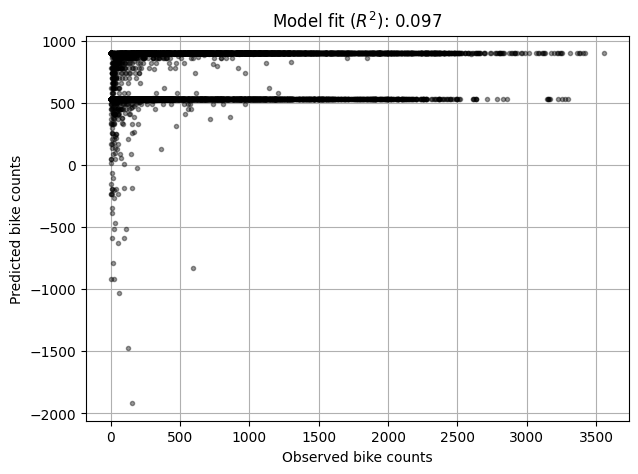

In [9]:
plt.figure(figsize=(7, 5))
plt.plot(y_bike, yhat_rain_season, 'ko', markersize=3, alpha=.4)
plt.xlabel('Observed bike counts')
plt.ylabel('Predicted bike counts')
plt.title(f'Model fit ($R^2$): {r2_rain_season:.3f}')
plt.grid(True)
plt.show()

## Regression Table Using statsmodels

Materi juga menunjukkan penggunaan `statsmodels` untuk menampilkan tabel regresi. Bagian penting yang perlu dilihat adalah nilai `R-squared` dan koefisien (`coef`) untuk tiap regressor.

In [10]:
if sm is None:
  raise ImportError('statsmodels belum tersedia di environment ini.')

# Extract data as pandas dataframe/series
desmat_df = data[['Rainfall(mm)', 'Seasons']]
obsdata_df = data['Rented Bike Count']

# Create and fit model. Intercept harus ditambahkan eksplisit.
desmat_df = sm.add_constant(desmat_df)
model = sm.OLS(obsdata_df, desmat_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Rented Bike Count   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     468.8
Date:                Sat, 30 May 2026   Prob (F-statistic):          3.80e-194
Time:                        02:15:20   Log-Likelihood:                -68654.
No. Observations:                8760   AIC:                         1.373e+05
Df Residuals:                    8757   BIC:                         1.373e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          530.4946      9.313     56.963   

## Multicollinearity

Multicollinearity berarti satu regressor dapat diprediksi secara linear dari regressor lain. Dalam bahasa linear algebra, ini sama dengan linear dependence, reduced-rank design matrix, atau singular design matrix. Jika design matrix reduced-rank, left-inverse tidak stabil atau tidak dapat dihitung langsung.

## Regularization

Regularization memodifikasi model untuk meningkatkan stabilitas numerik, mengubah matrix yang singular/ill-conditioned menjadi lebih stabil, atau mengurangi overfitting. Materi menggunakan bentuk:

$$\beta = (X^TX + \gamma \lVert X \rVert_F^2 I)^{-1}X^Ty$$

Parameter $\gamma$ menentukan besar regularization. Jika $\gamma = 0$, model kembali menjadi least squares biasa.

## Polynomial Regression

Polynomial regression adalah regresi biasa, tetapi kolom design matrix dibuat dari nilai x yang dipangkatkan: $x^0, x^1, x^2, \ldots, x^n$. Model orde ke-n memiliki n+1 regressor termasuk intercept.

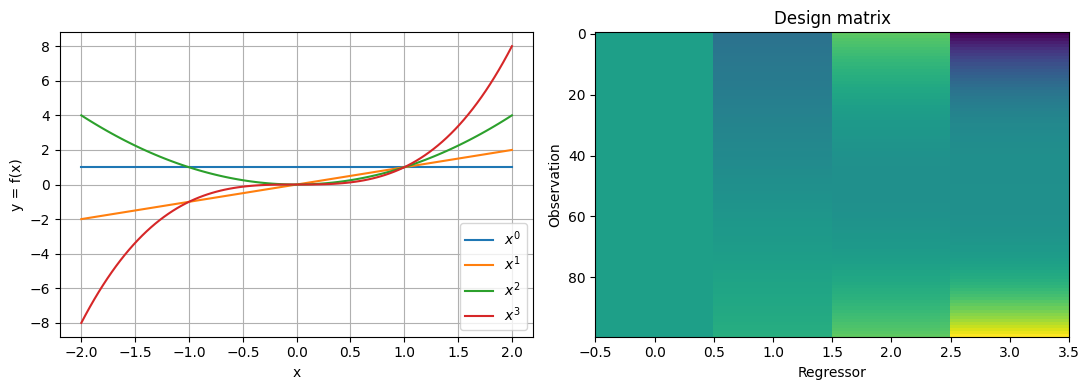

In [11]:
# Contoh design matrix polynomial orde 3 seperti materi.
x = np.linspace(-2, 2, 100)
X_poly_demo = np.zeros((len(x), 4))

for i in range(4):
  X_poly_demo[:, i] = x**i

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for i in range(4):
  axes[0].plot(x, X_poly_demo[:, i], label=f'$x^{i}$')

axes[0].set_xlabel('x')
axes[0].set_ylabel('y = f(x)')
axes[0].legend()
axes[0].grid(True)

axes[1].imshow(X_poly_demo, aspect='auto')
axes[1].set_title('Design matrix')
axes[1].set_xlabel('Regressor')
axes[1].set_ylabel('Observation')

plt.tight_layout()
plt.show()

## Polynomial Regression pada Data Doubling Time

Materi menggunakan dataset kecil tentang waktu doubling populasi manusia dan memilih polynomial orde 3. Cell berikut membuat design matrix polynomial dan melakukan fitting dengan `np.linalg.lstsq`.

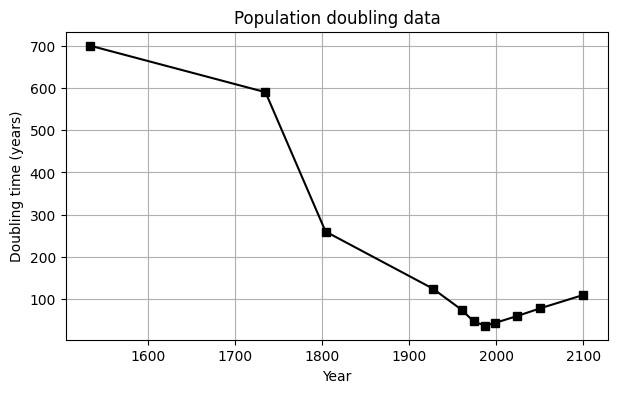

In [12]:
# Data kecil sesuai contoh population doubling pada materi.
# Jika sudah memiliki variabel year dan doubleTime sendiri, cell ini boleh dilewati.
year = np.array([1534, 1735, 1804, 1927, 1960, 1974, 1987, 1999, 2024, 2050, 2100])
doubleTime = np.array([700, 590, 260, 125, 75, 47, 37, 44, 60, 78, 110])
N = len(year)

plt.figure(figsize=(7, 4))
plt.plot(year, doubleTime, 'ks-')
plt.xlabel('Year')
plt.ylabel('Doubling time (years)')
plt.title('Population doubling data')
plt.grid(True)
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1791/2571598234.py:12: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(year, yhat_pop, 'o-', label='$\hat{y}$')


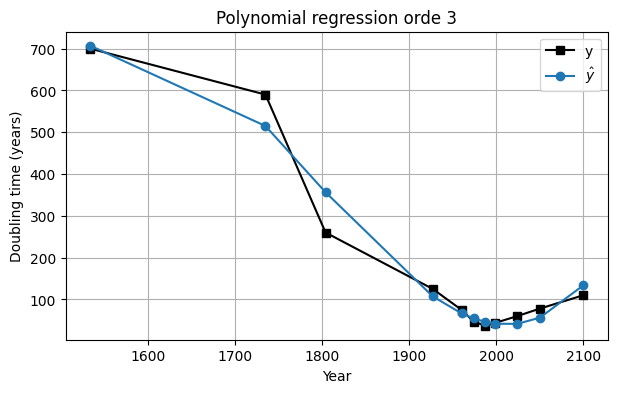

Beta polynomial orde 3:
[-89206.118    154.598     -0.088      0.   ]


In [13]:
# Design matrix polynomial orde 3
X_pop = np.zeros((N, 4))
for i in range(4):
  X_pop[:, i] = np.array(year)**i

# Fit model dan hitung predicted data
beta_pop = np.linalg.lstsq(X_pop, doubleTime, rcond=None)[0]
yhat_pop = X_pop @ beta_pop

plt.figure(figsize=(7, 4))
plt.plot(year, doubleTime, 'ks-', label='y')
plt.plot(year, yhat_pop, 'o-', label='$\hat{y}$')
plt.xlabel('Year')
plt.ylabel('Doubling time (years)')
plt.title('Polynomial regression orde 3')
plt.legend()
plt.grid(True)
plt.show()

print('Beta polynomial orde 3:')
print(beta_pop)

<>:10: SyntaxWarning: invalid escape sequence '\h'


Beta dari np.polyfit:
[     0.        -0.088    154.598 -89206.118]


<>:10: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1791/3526877677.py:10: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(year, yhat_np_poly, 'o-', label='$\hat{y}$ via np.polyfit')


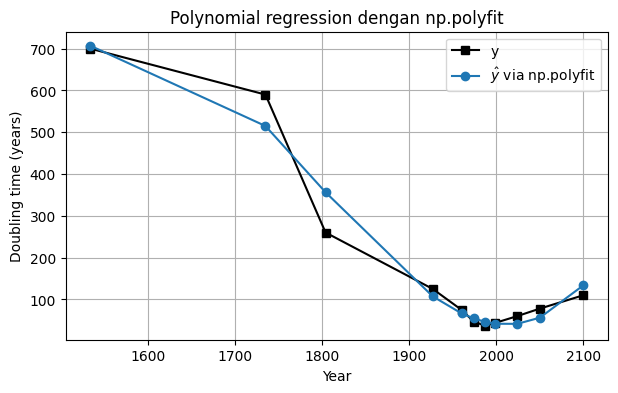

In [14]:
# Fungsi bawaan NumPy untuk polynomial regression.
beta_np_poly = np.polyfit(year, doubleTime, 3)
yhat_np_poly = np.polyval(beta_np_poly, year)

print('Beta dari np.polyfit:')
print(beta_np_poly)

plt.figure(figsize=(7, 4))
plt.plot(year, doubleTime, 'ks-', label='y')
plt.plot(year, yhat_np_poly, 'o-', label='$\hat{y}$ via np.polyfit')
plt.xlabel('Year')
plt.ylabel('Doubling time (years)')
plt.title('Polynomial regression dengan np.polyfit')
plt.legend()
plt.grid(True)
plt.show()

## Grid Search to Find Model Parameters

Grid search mencari parameter model dengan mencoba banyak kombinasi parameter, menghitung error untuk setiap kombinasi, lalu memilih kombinasi dengan error paling kecil. Pada contoh materi, grid search dibandingkan dengan solusi analitik least squares.

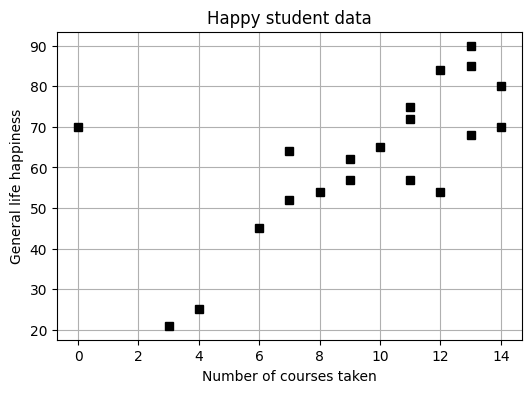

In [15]:
# Dataset “happy student” dari contoh sebelumnya.
numcourses = np.array([0, 4, 12, 3, 14, 13, 12, 9, 11, 7,
                       13, 11, 9, 13, 11, 10, 8, 7, 6, 14])

happiness = np.array([70, 25, 54, 21, 80, 68, 84, 62, 57, 64,
                      85, 75, 57, 90, 72, 65, 54, 52, 45, 70])

plt.figure(figsize=(6, 4))
plt.plot(numcourses, happiness, 'ks')
plt.xlabel('Number of courses taken')
plt.ylabel('General life happiness')
plt.title('Happy student data')
plt.grid(True)
plt.show()

# Code Exercises

## Exercise 12-1

Ulangi analisis bike rental, tetapi pilih hanya baris dengan `Rainfall(mm) == 0`. Lalu bandingkan apakah hasil membaik dari sisi $R^2$ dan apakah prediksi menjadi positif.

Beta [Rainfall, Seasons, Intercept]:
[  0.    412.656 537.395]

R^2: 0.1017324396474627
Prediksi minimum: 537.3946241674595


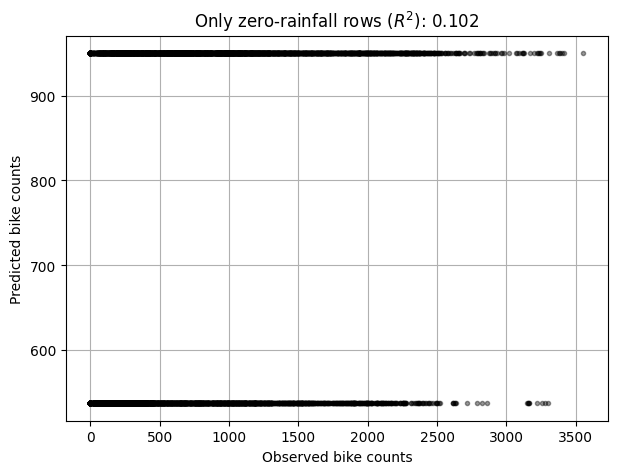

In [16]:
# Exercise 12-1
rain_zero = data[data['Rainfall(mm)'] == 0].copy()

X_no_rain = rain_zero[['Rainfall(mm)', 'Seasons']].to_numpy()
X_no_rain = np.append(X_no_rain, np.ones((X_no_rain.shape[0], 1)), axis=1)
y_no_rain = rain_zero[['Rented Bike Count']].to_numpy()

beta_no_rain, yhat_no_rain, r2_no_rain = fit_lstsq(X_no_rain, y_no_rain)

print('Beta [Rainfall, Seasons, Intercept]:')
print(beta_no_rain.reshape(-1))
print('\nR^2:', r2_no_rain)
print('Prediksi minimum:', np.min(yhat_no_rain))

plt.figure(figsize=(7, 5))
plt.plot(y_no_rain, yhat_no_rain, 'ko', markersize=3, alpha=.4)
plt.xlabel('Observed bike counts')
plt.ylabel('Predicted bike counts')
plt.title(f'Only zero-rainfall rows ($R^2$): {r2_no_rain:.3f}')
plt.grid(True)
plt.show()

## Exercise 12-2

Ganti `Seasons` dengan `Temperature(°C)` pada design matrix, lalu ulangi regresi menggunakan semua data.

Beta [Rainfall, Temperature, Intercept]:
[-86.062  29.49  337.483]

R^2: 0.3126481542486901
Prediksi minimum: -2031.798439370676


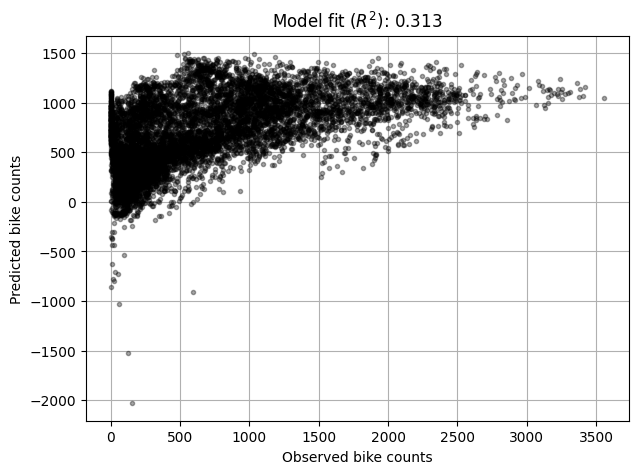

In [17]:
# Exercise 12-2
X_temp = data[['Rainfall(mm)', 'Temperature(°C)']].to_numpy()
X_temp = np.append(X_temp, np.ones((X_temp.shape[0], 1)), axis=1)
y_temp = data[['Rented Bike Count']].to_numpy()

beta_temp, yhat_temp, r2_temp = fit_lstsq(X_temp, y_temp)

print('Beta [Rainfall, Temperature, Intercept]:')
print(beta_temp.reshape(-1))
print('\nR^2:', r2_temp)
print('Prediksi minimum:', np.min(yhat_temp))

plt.figure(figsize=(7, 5))
plt.plot(y_temp, yhat_temp, 'ko', markersize=3, alpha=.35)
plt.xlabel('Observed bike counts')
plt.ylabel('Predicted bike counts')
plt.title(f'Model fit ($R^2$): {r2_temp:.3f}')
plt.grid(True)
plt.show()

## Exercise 12-3

Buat design matrix baru dengan regressor keempat yang merupakan linear weighted combination dari `Temperature(°C)` dan `Rainfall(mm)`. Konfirmasi bahwa design matrix memiliki 4 kolom tetapi rank 3, lalu bandingkan fit model dengan left-inverse, `np.linalg.lstsq`, dan `statsmodels`.

In [18]:
# Exercise 12-3
rainfall = data['Rainfall(mm)'].to_numpy()
temperature = data['Temperature(°C)'].to_numpy()
intercept = np.ones(len(data))

combined_regressor = temperature + rainfall

X_multi = np.column_stack((rainfall, temperature, intercept, combined_regressor))
y_multi = data[['Rented Bike Count']].to_numpy()

print('Design matrix size:', X_multi.shape)
print('Design matrix rank:', np.linalg.matrix_rank(X_multi))
print('\nDesign matrix correlation matrix:')
print(np.round(np.corrcoef(X_multi, rowvar=False), 5))

Design matrix size: (8760, 4)
Design matrix rank: 3

Design matrix correlation matrix:
[[1.    0.05    nan 0.143]
 [0.05  1.      nan 0.996]
 [  nan   nan   nan   nan]
 [0.143 0.996   nan 1.   ]]


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [19]:
# Fit dengan tiga pendekatan.
try:
  beta_left = np.linalg.inv(X_multi.T @ X_multi) @ X_multi.T @ y_multi
  yhat_left = X_multi @ beta_left
  r2_left = r2_score_manual(y_multi, yhat_left)
except np.linalg.LinAlgError:
  beta_left = np.full((X_multi.shape[1], 1), np.nan)
  r2_left = np.nan
  print('Left-inverse gagal karena design matrix reduced-rank/singular.')

beta_lstsq = np.linalg.lstsq(X_multi, y_multi, rcond=None)[0]
yhat_lstsq = X_multi @ beta_lstsq
r2_lstsq = r2_score_manual(y_multi, yhat_lstsq)

if sm is not None:
  model_multi = sm.OLS(y_multi, X_multi).fit()
  beta_sm = model_multi.params
  yhat_sm = model_multi.predict(X_multi)
  r2_sm = r2_score_manual(y_multi, yhat_sm)
else:
  beta_sm = np.full(X_multi.shape[1], np.nan)
  r2_sm = np.nan

print('MODEL FIT TO DATA:')
print(f'  Left-inverse: {r2_left}')
print(f'  np lstsq    : {r2_lstsq:.4f}')
print(f'  statsmodels : {r2_sm:.4f}')

print('\nBETA COEFFICIENTS:')
print('  Left-inverse:', np.round(beta_left.reshape(-1), 3))
print('  np lstsq    :', np.round(beta_lstsq.reshape(-1), 3))
print('  statsmodels :', np.round(beta_sm, 3))

MODEL FIT TO DATA:
  Left-inverse: -34.86755023496745
  np lstsq    : 0.3126
  statsmodels : 0.3126

BETA COEFFICIENTS:
  Left-inverse: [3265.613  -37.988  337.483   38.865]
  np lstsq    : [-67.204  48.347 337.483 -18.857]
  statsmodels : [-67.204  48.347 337.483 -18.857]


## Exercise 12-4

Terapkan regularization pada design matrix dengan dan tanpa multicollinearity. Gunakan rentang $\gamma$ dari 0 sampai 0.2, lalu lihat perubahan $R^2$.

In [20]:
# Exercise 12-4

def regularized_beta(X, y, gamma):
  XTX = X.T @ X
  I = np.eye(XTX.shape[0])
  reg = gamma * (np.linalg.norm(X, 'fro')**2) * I
  M = XTX + reg
  try:
    Minv = np.linalg.inv(M)
  except np.linalg.LinAlgError:
    Minv = np.linalg.pinv(M)
  return Minv @ X.T @ y, Minv

for gamma in [0, .01]:
  _, Minv = regularized_beta(X_multi, y_multi, gamma)
  print(f"inv(X'X + {gamma}*I) size: {Minv.shape}")
  print(f"inv(X'X + {gamma}*I) rank: {np.linalg.matrix_rank(Minv)}\n")

inv(X'X + 0*I) size: (4, 4)
inv(X'X + 0*I) rank: 3

inv(X'X + 0.01*I) size: (4, 4)
inv(X'X + 0.01*I) rank: 4



<>:17: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_1791/655932894.py:17: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel('Regularization $\gamma$')


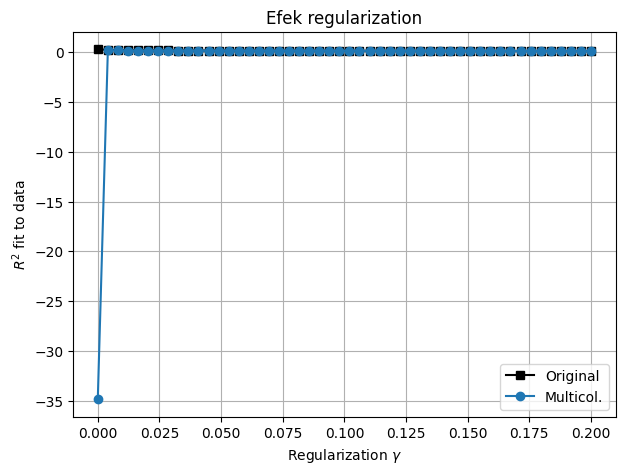

In [21]:
gammas = np.linspace(0, .2, 50)
r2_original = np.zeros(len(gammas))
r2_multicol = np.zeros(len(gammas))

for gi, gamma in enumerate(gammas):
  beta_o, _ = regularized_beta(X_temp, y_temp, gamma)
  yhat_o = X_temp @ beta_o
  r2_original[gi] = r2_score_manual(y_temp, yhat_o)

  beta_m, _ = regularized_beta(X_multi, y_multi, gamma)
  yhat_m = X_multi @ beta_m
  r2_multicol[gi] = r2_score_manual(y_multi, yhat_m)

plt.figure(figsize=(7, 5))
plt.plot(gammas, r2_original, 'ks-', label='Original')
plt.plot(gammas, r2_multicol, 'o-', label='Multicol.')
plt.xlabel('Regularization $\gamma$')
plt.ylabel('$R^2$ fit to data')
plt.title('Efek regularization')
plt.legend()
plt.grid(True)
plt.show()

## Exercise 12-5

Fit polynomial regression dari order 0 sampai 9. Latihan ini menunjukkan underfitting pada order rendah dan risiko overfitting pada order tinggi.

<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1791/4290769135.py:16: SyntaxWarning: invalid escape sequence '\h'
  axes[order].plot(year, yhat_order, 'o-', label='$\hat{y}$')


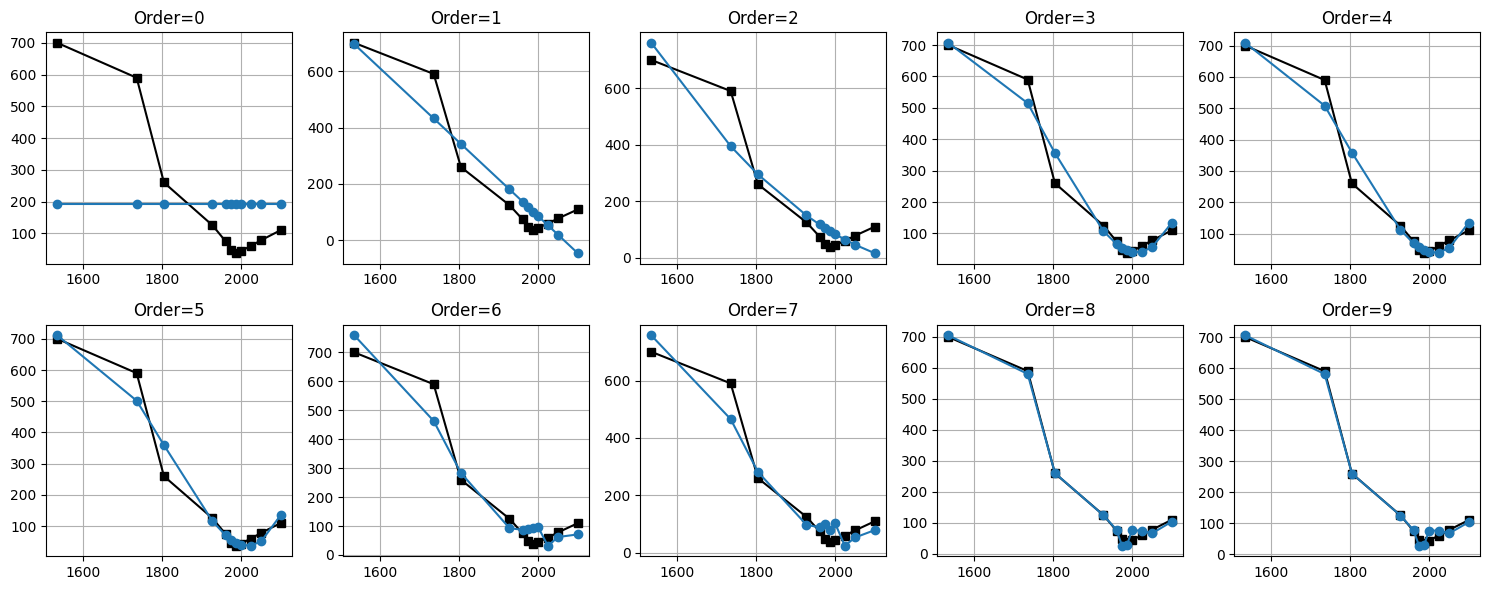

In [22]:
# Exercise 12-5
orders = range(10)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for order in orders:
  X_order = np.zeros((len(year), order + 1))

  for i in range(order + 1):
    X_order[:, i] = year**i

  beta_order = np.linalg.lstsq(X_order, doubleTime, rcond=None)[0]
  yhat_order = X_order @ beta_order

  axes[order].plot(year, doubleTime, 'ks-', label='y')
  axes[order].plot(year, yhat_order, 'o-', label='$\hat{y}$')
  axes[order].set_title(f'Order={order}')
  axes[order].grid(True)

plt.tight_layout()
plt.show()

## Exercise 12-6

Reproduksi grid search pada dataset “happy student”. Grid search mengevaluasi banyak pasangan intercept dan slope, lalu memilih pasangan dengan SSE terkecil. Hasilnya dibandingkan dengan solusi analitik least squares.

Analytic result:
  Intercept: 34.13, slope: 3.03
Empirical result:
  Intercept: 33.94, slope: 3.03


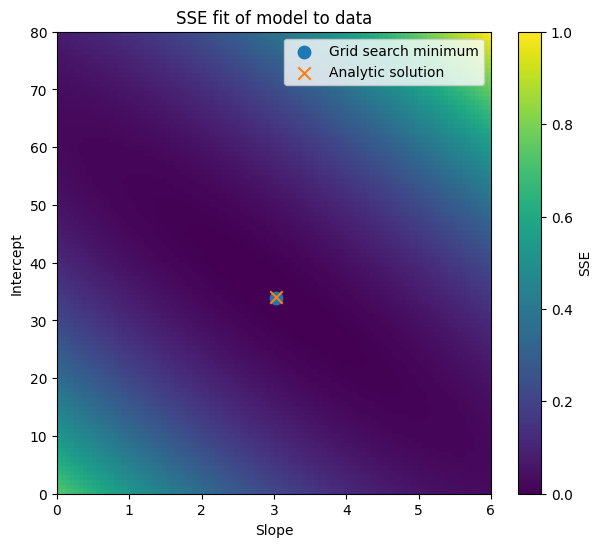

In [23]:
# Exercise 12-6
resolution = 100
intercepts = np.linspace(0, 80, resolution)
slopes = np.linspace(0, 6, resolution)
sse_grid = np.zeros((resolution, resolution))

x_happy = np.array(numcourses)
y_happy = np.array(happiness)

for ii, intercept_value in enumerate(intercepts):
  for jj, slope_value in enumerate(slopes):
    yhat_grid = intercept_value + slope_value*x_happy
    sse_grid[ii, jj] = np.sum((y_happy - yhat_grid)**2)

best_idx = np.unravel_index(np.argmin(sse_grid), sse_grid.shape)
best_intercept = intercepts[best_idx[0]]
best_slope = slopes[best_idx[1]]

X_happy = np.column_stack((np.ones(len(x_happy)), x_happy))
beta_analytic = np.linalg.inv(X_happy.T @ X_happy) @ X_happy.T @ y_happy

print('Analytic result:')
print(f'  Intercept: {beta_analytic[0]:.2f}, slope: {beta_analytic[1]:.2f}')
print('Empirical result:')
print(f'  Intercept: {best_intercept:.2f}, slope: {best_slope:.2f}')

plt.figure(figsize=(7, 6))
plt.imshow(
  sse_grid,
  origin='lower',
  aspect='auto',
  extent=[slopes[0], slopes[-1], intercepts[0], intercepts[-1]]
)
plt.scatter(best_slope, best_intercept, s=80, marker='o', label='Grid search minimum')
plt.scatter(beta_analytic[1], beta_analytic[0], s=80, marker='x', label='Analytic solution')
plt.xlabel('Slope')
plt.ylabel('Intercept')
plt.title('SSE fit of model to data')
plt.colorbar(label='SSE')
plt.legend()
plt.show()

## Exercise 12-7

Ganti SSE pada grid search dengan $R^2$ berbasis korelasi, lalu periksa mengapa hasilnya buruk. Masalahnya: squared correlation tidak memperhatikan skala dan offset prediksi. Karena itu, banyak kombinasi intercept-slope bisa tampak sama baiknya walaupun nilai prediksinya jauh dari data observasi.

Hasil grid search dengan R^2 berbasis korelasi:
  Intercept: 60.61, slope: 0.30

Solusi analytic least squares:
  Intercept: 34.13, slope: 3.03

SSE dari solusi R^2-grid: 5695.992653810835
SSE dari solusi least squares: 3540.6114116210083


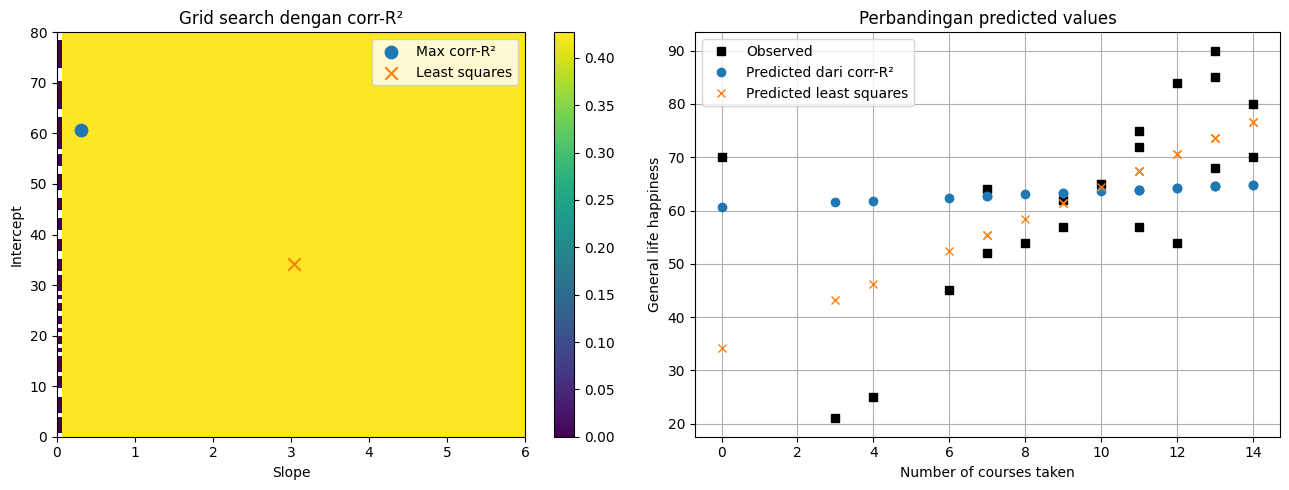

In [24]:
# Exercise 12-7
r2_grid_corr = np.zeros((resolution, resolution))

for ii, intercept_value in enumerate(intercepts):
  for jj, slope_value in enumerate(slopes):
    yhat_grid = intercept_value + slope_value*x_happy

    if np.std(yhat_grid) == 0:
      r2_grid_corr[ii, jj] = np.nan
    else:
      r2_grid_corr[ii, jj] = np.corrcoef(y_happy, yhat_grid)[0, 1]**2

best_r2_idx = np.unravel_index(np.nanargmax(r2_grid_corr), r2_grid_corr.shape)
best_r2_intercept = intercepts[best_r2_idx[0]]
best_r2_slope = slopes[best_r2_idx[1]]
yhat_bad = best_r2_intercept + best_r2_slope*x_happy

print('Hasil grid search dengan R^2 berbasis korelasi:')
print(f'  Intercept: {best_r2_intercept:.2f}, slope: {best_r2_slope:.2f}')
print('\nSolusi analytic least squares:')
print(f'  Intercept: {beta_analytic[0]:.2f}, slope: {beta_analytic[1]:.2f}')
print('\nSSE dari solusi R^2-grid:', np.sum((y_happy - yhat_bad)**2))
print('SSE dari solusi least squares:', np.sum((y_happy - X_happy @ beta_analytic)**2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(
  r2_grid_corr,
  origin='lower',
  aspect='auto',
  extent=[slopes[0], slopes[-1], intercepts[0], intercepts[-1]]
)
axes[0].scatter(best_r2_slope, best_r2_intercept, marker='o', s=80, label='Max corr-R²')
axes[0].scatter(beta_analytic[1], beta_analytic[0], marker='x', s=80, label='Least squares')
axes[0].set_xlabel('Slope')
axes[0].set_ylabel('Intercept')
axes[0].set_title('Grid search dengan corr-R²')
axes[0].legend()
plt.colorbar(im, ax=axes[0])

axes[1].plot(x_happy, y_happy, 'ks', label='Observed')
axes[1].plot(x_happy, yhat_bad, 'o', label='Predicted dari corr-R²')
axes[1].plot(x_happy, X_happy @ beta_analytic, 'x', label='Predicted least squares')
axes[1].set_xlabel('Number of courses taken')
axes[1].set_ylabel('General life happiness')
axes[1].set_title('Perbandingan predicted values')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()